# Analitika financija - Druga laboratorijska vježba

---


<b>Uvod i upute za predaju</b>

Druga laboratorijska vježba iz Analitike financija sastoji se od tri zadataka koje je potrebno riješiti u programskom jeziku Python, rješavajući zadatke unutar Juypyter bilježnice. 

Rješavanje vježbe svodi se na čitanje uputa u ćelijama s tekstom, nadopunjavanje blokova kôda (možete dodavati i dodatne blokove kôda ukoliko je potrebno) i ispisivanje rezultata (u vidu ispisa iz funkcija, tablica i grafova). Pritom morate razumjeti teorijske osnove implementiranih rješenja, u okviru onoga što je obrađeno na predavanjima.

Zadatci u samoj vježbi su istraživačkog tipa - ne postoji nužno samo jedan točan način rješavanja svakog zadatka, zato potičemo studente na eksperimentiranje. 

Osim ako u određenom zadatku ne piše drugačije, za implementaciju rješenja možete koristiti proizvoljne biblioteke.

Vaše rješenje (bilježnicu) potrebno je poslati na e-mail adresu `tomislav.kovacevic@fer.hr` u formatu naziva `IME_PREZIME_JMBAG.ipynb`. Na istu e-mail adresu možete se javiti s bilo kakvim pitanjima vezanim uz ovu vježbu.

Na ovoj vježbi možete ostvariti ukupno 20 bodova. Vaša Jupyter bilježnica ocjenjivat će se s mogućnošću ostvarivanja do 10 bodova, a na usmenoj obrani moguće je ostvariti preostalih 10 bodova. 

Napominjemo da će se prilikom ocjenjivanja strogo provjeravati originalnost vaših rješenja. Predstavljanje tuđeg rada kao vlastitog je kršenje kodeksa ponašanja studenata i takvi slučajevi bit će prijavljeni povjerenstvu za stegovnu odgovornost.

Vježbu radite samostalno, a svoje rješenje branite na terminima koji su vam dodijeljeni u kalendaru. Podsjećamo da bodovi iz laboratorijskih vježbi ulaze i u bodove na ispitnom roku, te da je za polaganje predmeta potrebno imati barem 30\% ukupnih bodova iz laboratorijskih vježbi. Nadoknade laboratorijskih vježbi neće biti organizirane.


In [308]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize
import yfinance as yf

## Zadatak 1

U ovom zadatku analizirat ćemo Value-at-Risk (VaR) i Expected Shortfall (ES), dvije ključne metrike za kvantificiranje tržišnog rizika. Cilj je procijeniti i usporediti različite metode za izračun VaR-a i ES-a, vizualizirati razlike među metodama te provjeriti koliko su procjene pouzdane kroz jednostavni backtest na novim podacima.

Value-at-Risk (VaR) definiramo kao negativni $(1-\alpha)$-kvantil distribucije povrata $F_R$:

$$
\text{VaR}_\alpha = -F_R^{-1}(1-\alpha),
$$

gdje je $F_R^{-1}$ inverzna funkcija distribucije povrata. 

Value-at-Risk (VaR) odgovara najvećem očekivanom gubitku u X% najgorih scenarija. Međutim, VaR ne daje informaciju o ekstremnim gubicima izvan tog praga. Expected Shortfall (ES) rješava taj problem jer mjeri prosječni gubitak u najgorih X% slučajeva.


Expected Shortfall (ES), poznat i kao Conditional Value-at-Risk (CVaR), definiran je kao prosječna vrijednost Value-at-Risk (VaR) za kvantile iznad razine $\alpha$:

$$
ES_{\alpha}(w) = \frac{1}{1 - \alpha} \int_{\alpha}^{1} \text{VaR}_u(w) \, du,
$$

gdje je:
- $ES_{\alpha}(w)$ – očekivani gubitak uvjetovan time da je ostvaren gubitak veći od VaR-a na razini pouzdanosti $\alpha$,
- $\text{VaR}_u(w)$ – Value-at-Risk na razini kvantila $u$,
- $\alpha$ – razina rizika.




1. Koristeći yfinance biblioteku dohvatite zadnje cijene u danu za dionice 'AAPL' i 'MSFT' u razdoblju 2023-01-01 do 2023-12-31.
2. Implementirajte neparametarsku metodu procjene VaR-a i ES-a objašnjenu u predavanju "05 Modeliranje i procjena rizika". 
3. Prikažite distribucije povrata i označite neparametarski dobivene VaR i ES pragove, za $\alpha=95\%$

In [309]:
start_date = '2023-01-01'
end_date = '2023-12-31'

df_2023 = yf.download(['AAPL', 'MSFT'], start=start_date, end=end_date)['Adj Close']

df_2023.index = df_2023.index.date

print(df_2023)

[*********************100%***********************]  2 of 2 completed

Ticker            AAPL        MSFT
2023-01-03  123.768456  235.711685
2023-01-04  125.045044  225.400940
2023-01-05  123.718971  218.720566
2023-01-06  128.271103  221.298218
2023-01-09  128.795593  223.452881
...                ...         ...
2023-12-22  192.656189  371.799713
2023-12-26  192.108841  371.879120
2023-12-27  192.208359  371.293518
2023-12-28  192.636261  372.494507
2023-12-29  191.591385  373.248871

[250 rows x 2 columns]


In [310]:
df_2023_returns = df_2023.pct_change().dropna()
print(df_2023_returns)

Ticker          AAPL      MSFT
2023-01-04  0.010314 -0.043743
2023-01-05 -0.010605 -0.029638
2023-01-06  0.036794  0.011785
2023-01-09  0.004089  0.009736
2023-01-10  0.004456  0.007617
...              ...       ...
2023-12-22 -0.005547  0.002784
2023-12-26 -0.002841  0.000214
2023-12-27  0.000518 -0.001575
2023-12-28  0.002226  0.003235
2023-12-29 -0.005424  0.002025

[249 rows x 2 columns]


In [311]:
def nonparametric_var_expected_shortfall(returns, confidence_level = 0.95):
    
    returns_sorted = sorted(returns)

    n = len(returns_sorted)
    q = int(np.floor(n * (1-confidence_level)))

    var = - ((q + 1 - n * (1 - confidence_level)) * returns_sorted[q-1] + (n * (1 - confidence_level) - q) * returns_sorted[q])

    es = - 1 / q * np.sum(returns_sorted[:q])

    return var, es


confidence_level = 0.95

for stock in df_2023_returns.columns:
    np_var, np_es = nonparametric_var_expected_shortfall(df_2023_returns[stock], confidence_level)

    print(f"VaR at {confidence_level*100}% confidence level: {np_var:.4f}")
    print(f"Expected Shortfall at {confidence_level*100}% confidence level: {np_es:.4f}\n")


VaR at 95.0% confidence level: 0.0175
Expected Shortfall at 95.0% confidence level: 0.0256

VaR at 95.0% confidence level: 0.0234
Expected Shortfall at 95.0% confidence level: 0.0297



1. Implementirajte parametarsku metodu procjene VaR-a i ES-a objašnjenu u predavanju "05 Modeliranje i procjena rizika". 
2. Prikažite distribucije povrata i označite parametarski dobivene VaR i ES pragove, za $\alpha=95\%$

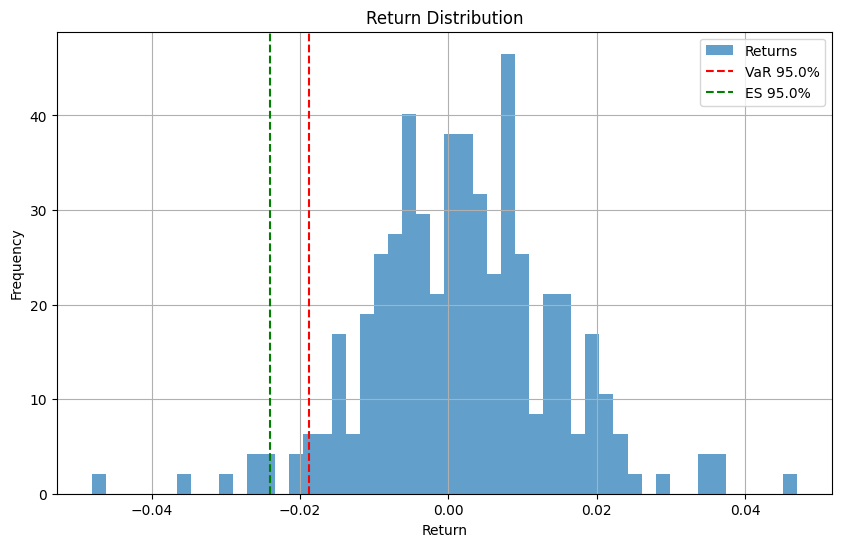

VaR at 95.0% confidence level: 0.0188
Expected Shortfall at 95.0% confidence level: 0.0240



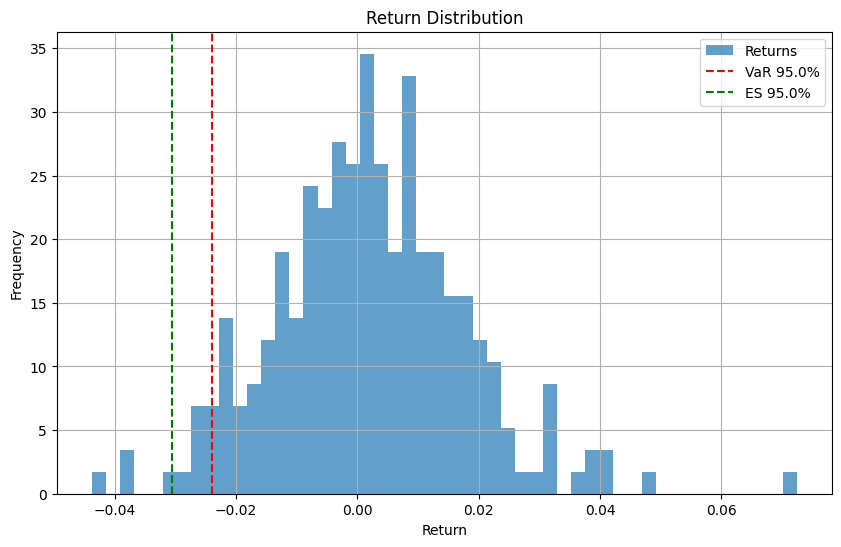

VaR at 95.0% confidence level: 0.0240
Expected Shortfall at 95.0% confidence level: 0.0306



In [312]:
def parametric_var_expected_shortfall(returns, confidence_level = 0.95):
    
    avg_return = np.mean(returns)
    stddev = np.std(returns)
    
    CDF_inverse = norm.ppf(confidence_level)
    
    var = - avg_return + CDF_inverse * stddev

    es = - avg_return + (norm.pdf(CDF_inverse) / (1 - confidence_level)) * stddev

    plt.figure(figsize=(10, 6))
    plt.hist(returns, bins=50, density=True, alpha=0.7, label='Returns')
    plt.axvline(-var, color='r', linestyle='--', label=f'VaR {confidence_level*100}%')
    plt.axvline(-es, color='g', linestyle='--', label=f'ES {confidence_level*100}%')
    
    plt.title('Return Distribution')
    plt.xlabel('Return')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return var, es

confidence_level = 0.95

for stock in df_2023_returns.columns:
    p_var, p_es = parametric_var_expected_shortfall(df_2023_returns[stock], confidence_level)

    print(f"VaR at {confidence_level*100}% confidence level: {p_var:.4f}")
    print(f"Expected Shortfall at {confidence_level*100}% confidence level: {p_es:.4f}\n")

1. Koristeći yfinance biblioteku dohvatite zadnje cijene u danu za dionice 'AAPL' i 'MSFT' u razdoblju 2024-01-01 do 2024-01-31.
2. Koristite ranije izračunate VaR vrijednosti kao prognoze rizika za novo razdoblje (2024-01-01 do 2024-01-31).
3. Izračunajte stvarne povrate i usporedite ih s parametarskim/neparametarskim VaR pragom.
2. Izračunajte u kojem postotku povrati u novom razdoblju prelaze parametarski/neparametarski VaR za svaku od dionica.

In [313]:
start_date = '2024-01-01'
end_date = '2024-01-31'

df_2024 = yf.download(['AAPL', 'MSFT'], start=start_date, end=end_date)['Adj Close']

df_2024.index = df_2024.index.date

df_2024_returns = df_2024.pct_change().dropna()
print(df_2024_returns)

print(f"Non-Parametric VaR at {confidence_level*100}% confidence level: {np_var:.4f}")
print(f"Parametric VaR at {confidence_level*100}% confidence level: {p_var:.4f}")

[*********************100%***********************]  2 of 2 completed

Ticker          AAPL      MSFT
2024-01-03 -0.007488 -0.000728
2024-01-04 -0.012700 -0.007178
2024-01-05 -0.004013 -0.000516
2024-01-08  0.024175  0.018872
2024-01-09 -0.002263  0.002936
2024-01-10  0.005672  0.018574
2024-01-11 -0.003223  0.004859
2024-01-12  0.001778  0.009984
2024-01-16 -0.012317  0.004634
2024-01-17 -0.005173 -0.002050
2024-01-18  0.032571  0.011297
2024-01-19  0.015533  0.012187
2024-01-22  0.012163 -0.005418
2024-01-23  0.006653  0.006027
2024-01-24 -0.003484  0.009175
2024-01-25 -0.001697  0.005738
2024-01-26 -0.009013 -0.002322
2024-01-29 -0.003586  0.014334
2024-01-30 -0.019246 -0.002758
Non-Parametric VaR at 95.0% confidence level: 0.0234
Parametric VaR at 95.0% confidence level: 0.0240


In [314]:
below_np_aapl = (df_2024_returns['AAPL'] < -np_var).mean() * 100
below_np_msft = (df_2024_returns['MSFT'] < -np_var).mean() * 100

below_p_aapl = (df_2024_returns['AAPL'] < -p_var).mean() * 100
below_p_msft = (df_2024_returns['MSFT'] < -p_var).mean() * 100

print("Percentage of returns below Non-Parametric VaR:")
print(f"AAPL: {below_np_aapl:.2f}%")
print(f"MSFT: {below_np_msft:.2f}%")

print("Percentage of returns below Non-Parametric VaR:")
print(f"AAPL: {below_p_aapl:.2f}%")
print(f"MSFT: {below_p_msft:.2f}%")

Percentage of returns below Non-Parametric VaR:
AAPL: 0.00%
MSFT: 0.00%
Percentage of returns below Non-Parametric VaR:
AAPL: 0.00%
MSFT: 0.00%


## Zadatak 2

Razmatramo jednu rizičnu imovinu za koju su poznati njezin očekivani povrat $\mu$ i standardna devijacija povrata $\sigma$, te jednu nerizičnu imovinu za koju je poznat povrat $r_f$.

Zanima nas kakve očekivane povrate i standardne devijacije može imati portfelj ove dvije imovine, ako s $w$ označimo izloženost rizičnoj imovini:

$$
    R_p = (1 - w)r_f + wR
$$
$$
    E(R_p) = r_f + w(\mu - r_f)
$$
$$
    \text{Var}(R_p) = w^2 \sigma^2.
$$

Nadalje, zanima nas koja je optimalna izloženost rizičnoj imovini ako investitori maksimiziraju očekivanu funkciju korisnosti:

$$
    E(U(R_p)) = E(R_p) - \frac{1}{2} \lambda \text{Var}(R_p).
$$

Problem se svodi na:

$$
    \max_w \quad r_f + w(\mu - r_f) - \frac{1}{2} \lambda w^2 \sigma^2, 
$$

a rješenje je:

$$
    w^* = \frac{\mu - r_f}{\lambda \sigma^2}, 
$$

gdje su: 

- $w^*$ - optimalna izloženost rizičnoj imovini,
- $\mu$ - očekivani povrat rizične imovine,
- $r_f$ - povrat nerizične imovine,
- $\lambda$ - koeficijent averzije prema riziku investitora,
- $\sigma$ - standardna devijacija povrata rizične imovine.

1. Koristeći yfinance biblioteku, dohvatite zadnje dnevne cijene za dionicu AAPL u razdoblju 2023-06-01 do 2023-12-31.
2. Izračunajte dnevne aritmetičke povrate.
3. Implementirajte funkciju risk_weight(mu, sigma, lmdb), koja računa optimalni udio u rizičnoj imovini prema formuli za $w^*$. 
4. Pretpostavite godišnju bezrizičnu stopu $r_f = 2\%$ te izračunajte optimalni udio u dionici Apple-a $w^*$ za razdoblje 2023-01-01 do 2023-12-31 uz pretpostavku $\lambda=4$.
- $\mu$ je očekivani godišnji povrat, izračunat kao prosječni dnevni povrat pomnožen s 252 (broj trgovačkih dana u godini),
- $\sigma$ je godišnja volatilnost, dobivena množenjem standardne devijacije dnevnih povrata s $\sqrt{252}$,
- $w^*$ je optimalna izloženost rizičnoj imovini koja treba biti u intervalu [0,1].  

In [315]:
start_date = '2023-06-01'
end_date = '2023-12-31'

df_aapl = yf.download(['AAPL'], start=start_date, end=end_date)['Adj Close']

df_aapl.index = df_aapl.index.date

df_aapl_returns = df_aapl.pct_change().dropna()
print(df_aapl_returns)

[*********************100%***********************]  1 of 1 completed

Ticker          AAPL
2023-06-02  0.004775
2023-06-05 -0.007571
2023-06-06 -0.002060
2023-06-07 -0.007756
2023-06-08  0.015465
...              ...
2023-12-22 -0.005547
2023-12-26 -0.002841
2023-12-27  0.000518
2023-12-28  0.002226
2023-12-29 -0.005424

[146 rows x 1 columns]


In [316]:
df_aapl_returns = df_aapl.pct_change().dropna()
print(df_aapl_returns)

Ticker          AAPL
2023-06-02  0.004775
2023-06-05 -0.007571
2023-06-06 -0.002060
2023-06-07 -0.007756
2023-06-08  0.015465
...              ...
2023-12-22 -0.005547
2023-12-26 -0.002841
2023-12-27  0.000518
2023-12-28  0.002226
2023-12-29 -0.005424

[146 rows x 1 columns]


In [317]:
def risk_weight(df_returns, risk_free_rate, lmdb):

    mu = df_returns.mean() * 252
    sigma = df_returns.std() * np.sqrt(252)

    w_optimal = (mu - risk_free_rate) / (lmdb * sigma**2)

    if w_optimal < 0:
        return 0, mu, sigma
    elif w_optimal > 1:
        return 1, mu, sigma
    return w_optimal, mu, sigma


In [318]:
lmdb = 4
risk_free_rate = 0.02

optimal_weight_apple, _, _ = risk_weight(df_aapl_returns['AAPL'], risk_free_rate, lmdb)

print(f"The optimal portfolio weight for Apple stock (w*) with λ=4 and rf=2% is: {optimal_weight_apple:.4f}")

The optimal portfolio weight for Apple stock (w*) with λ=4 and rf=2% is: 0.8630


1. Koristeći yfinance biblioteku, dohvatite zadnje dnevne cijene za dionicu Coca-Cole (ticker:"KO") za razdoblje od 2004-01-01 do 2024-12-31. 
2. Izračunajte dnevne aritmetičke povrate. 
4. Implementirajte simulaciju rasta portfelja, uz pretpostavljeno početno stanje portfelja $V_0=1000$ te uz koeficijent averzije prema riziku $\lambda=2$:

$$
V_{t+1} = V_t \left[1 + \left(w^* r_t + (1 - w^*) r_f\right) \right],
$$

gdje je:
- $V_t$ - vrijednost portfelja u trenutku \( t \),
- $w^*$ - optimalna težina rizične imovine u portfelju,
- $r_t$ - aritmetički povrat rizične imovine u trenutku \( t \),
- $r_f$ - bezrizična stopa povrata,
- $V_{t+1}$ - nova vrijednost portfelja.

Na početku svake godine potrebno je izračunati $w^*$ i tako izračunat $w^*$ primijeniti za izračun nove vrijednost portfelja, ako pretpostavite da će narednih godinu dana udio rizične imovine biti $w^*$, odnosno nerizične $(1-w^*)$. 

4. Izvršite tri različite simulacije rasta, uz pretpostavljenu godišnju bezrizičnu godišnju stopu $r_f=2\%$:
- Korištenjem očekivani godišnji povrat $\mu$ i godišnje volatilnosti $\sigma$ izračunatih iz dnevnih aritmetičkih povrata, uz rebalans portfelja prema izračunatom $w^*$.
- Postavljanje fiksne godišnje stope rasta $\mu = 8\%$, ali izračun godišnje volatilnosti $\sigma$ iz dnevnih aritmetičkih povrata, uz rebalans portfelja prema izračunatom $w^*$.
- Postavljanje $\mu = 8\%$ i volatilnosti $\sigma = 15\%$, bez godišnjeg rebalansa portfelja.
5. Iscrtajte tri krivulje koje prikazuju rast portfelja za prethodne tri metode tijekom godina uz $\lambda=2$. 
6. Iscrtajte tri krivulje koje prikazuju rast portfelja za prethodne tri metode tijekom godina uz $\lambda=1$. 


In [319]:
start_date = '2004-01-01'
end_date = '2024-12-31'

df_ko = yf.download(['KO'], start=start_date, end=end_date)['Adj Close']

df_ko_returns = df_ko.pct_change().dropna()
print(df_ko_returns)

[*********************100%***********************]  1 of 1 completed

Ticker                           KO
Date                               
2004-01-05 00:00:00+00:00  0.001192
2004-01-06 00:00:00+00:00 -0.004166
2004-01-07 00:00:00+00:00 -0.006375
2004-01-08 00:00:00+00:00  0.004812
2004-01-09 00:00:00+00:00 -0.010575
...                             ...
2024-12-23 00:00:00+00:00 -0.002718
2024-12-24 00:00:00+00:00  0.007374
2024-12-26 00:00:00+00:00 -0.004297
2024-12-27 00:00:00+00:00 -0.001918
2024-12-30 00:00:00+00:00 -0.006725

[5283 rows x 1 columns]


In [320]:
def portfolio_growth_simulation(df_returns, risk_free_rate, lmdb, portfolio_value=1000, fixed_annual_growth_rate=-1, fixed_volatility=-1, portfolio_rebalancing=True):

    portfolio_values = [portfolio_value]
    years = []

    for year, year_data in df_returns.groupby(df_returns.index.year):
        if portfolio_rebalancing or len(portfolio_values)==1:
            w_opt, mu, sigma = risk_weight(year_data, risk_free_rate, lmdb)
        
        if fixed_annual_growth_rate!=-1 and fixed_volatility!=-1:
            w_opt = (fixed_annual_growth_rate - risk_free_rate) / (lmdb * fixed_volatility**2)
        
        elif fixed_annual_growth_rate==-1 and fixed_volatility!=-1:
            w_opt = (mu - risk_free_rate) / (lmdb * fixed_volatility**2)
        
        elif fixed_annual_growth_rate!=-1 and fixed_volatility==-1:
            w_opt = (fixed_annual_growth_rate - risk_free_rate) / (lmdb * sigma**2)
        
        if w_opt < 0:
            w_opt = 0
        elif w_opt > 1:
            w_opt = 1
        
        portfolio_value = portfolio_value * (1 + (w_opt * df_returns.mean()*252 + (1-w_opt) * risk_free_rate))

        portfolio_values.append(portfolio_value)
        years.append(year)

    years.append(year+1)

    return portfolio_values, years

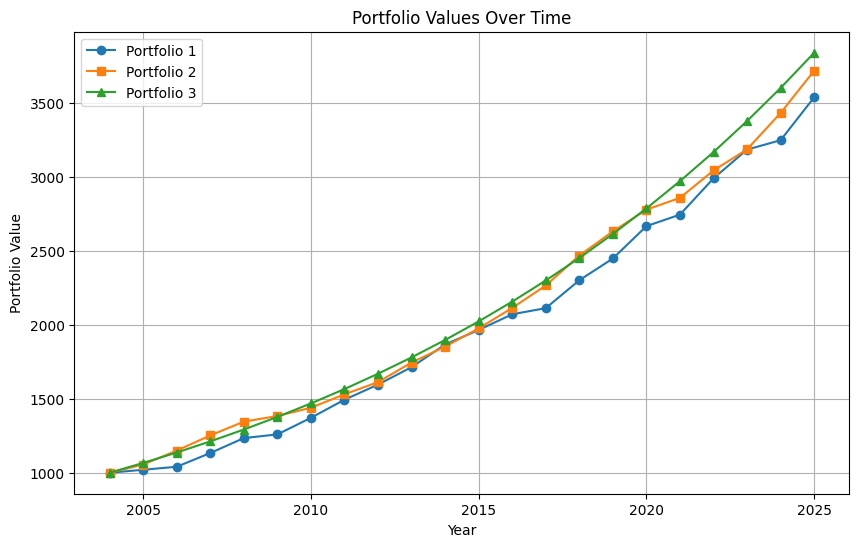

In [321]:
lmdb = 4
risk_free_rate = 0.02

portfolio_values_1, years = portfolio_growth_simulation(df_ko_returns['KO'], risk_free_rate, lmdb, portfolio_value=1000, fixed_annual_growth_rate=-1, fixed_volatility=-1, portfolio_rebalancing=True)

portfolio_values_2, _ = portfolio_growth_simulation(df_ko_returns['KO'], risk_free_rate, lmdb, portfolio_value=1000, 
                            fixed_annual_growth_rate=0.08, fixed_volatility=-1, portfolio_rebalancing=True)

portfolio_values_3, _ = portfolio_growth_simulation(df_ko_returns['KO'], risk_free_rate, lmdb, portfolio_value=1000, 
                            fixed_annual_growth_rate=0.08, fixed_volatility=0.15, portfolio_rebalancing=False)

plt.figure(figsize=(10, 6)) 

plt.plot(years, portfolio_values_1, label='Portfolio 1', marker='o')
plt.plot(years, portfolio_values_2, label='Portfolio 2', marker='s')
plt.plot(years, portfolio_values_3, label='Portfolio 3', marker='^')

plt.title('Portfolio Values Over Time')
plt.xlabel('Year')
plt.ylabel('Portfolio Value')
plt.grid(True)
plt.legend()

plt.show()

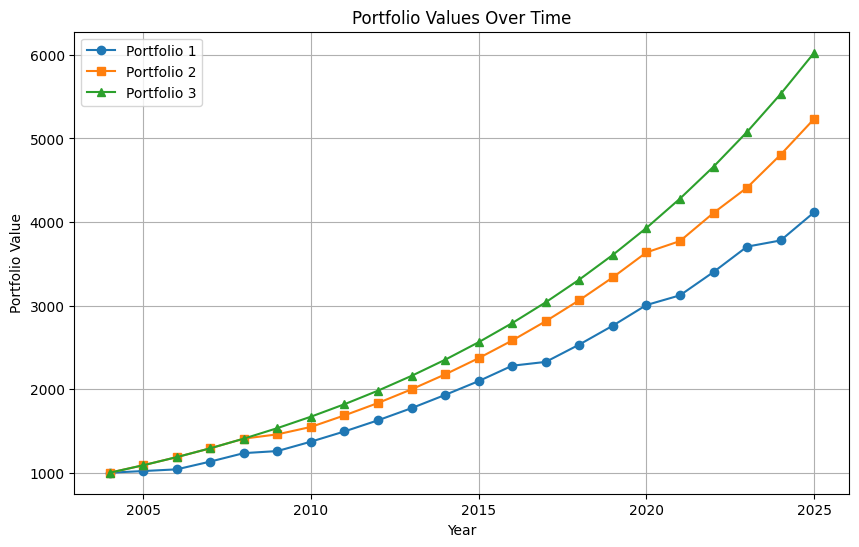

In [322]:
lmdb = 2
risk_free_rate = 0.02

portfolio_values_1, years = portfolio_growth_simulation(df_ko_returns['KO'], risk_free_rate, lmdb, portfolio_value=1000, fixed_annual_growth_rate=-1, fixed_volatility=-1, portfolio_rebalancing=True)

portfolio_values_2, _ = portfolio_growth_simulation(df_ko_returns['KO'], risk_free_rate, lmdb, portfolio_value=1000, 
                            fixed_annual_growth_rate=0.08, fixed_volatility=-1, portfolio_rebalancing=True)

portfolio_values_3, _ = portfolio_growth_simulation(df_ko_returns['KO'], risk_free_rate, lmdb, portfolio_value=1000, 
                            fixed_annual_growth_rate=0.08, fixed_volatility=0.15, portfolio_rebalancing=False)

plt.figure(figsize=(10, 6)) 

plt.plot(years, portfolio_values_1, label='Portfolio 1', marker='o')
plt.plot(years, portfolio_values_2, label='Portfolio 2', marker='s')
plt.plot(years, portfolio_values_3, label='Portfolio 3', marker='^')

plt.title('Portfolio Values Over Time')
plt.xlabel('Year')
plt.ylabel('Portfolio Value')
plt.grid(True)
plt.legend()

plt.show()

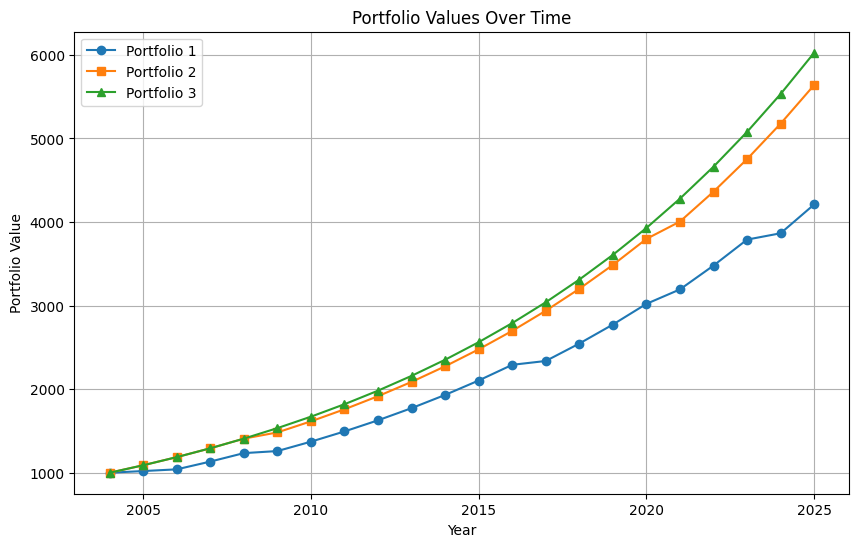

In [323]:
lmdb = 1
risk_free_rate = 0.02

portfolio_values_1, years = portfolio_growth_simulation(df_ko_returns['KO'], risk_free_rate, lmdb, portfolio_value=1000, fixed_annual_growth_rate=-1, fixed_volatility=-1, portfolio_rebalancing=True)

portfolio_values_2, _ = portfolio_growth_simulation(df_ko_returns['KO'], risk_free_rate, lmdb, portfolio_value=1000, 
                            fixed_annual_growth_rate=0.08, fixed_volatility=-1, portfolio_rebalancing=True)

portfolio_values_3, _ = portfolio_growth_simulation(df_ko_returns['KO'], risk_free_rate, lmdb, portfolio_value=1000, 
                            fixed_annual_growth_rate=0.08, fixed_volatility=0.15, portfolio_rebalancing=False)

plt.figure(figsize=(10, 6)) 

plt.plot(years, portfolio_values_1, label='Portfolio 1', marker='o')
plt.plot(years, portfolio_values_2, label='Portfolio 2', marker='s')
plt.plot(years, portfolio_values_3, label='Portfolio 3', marker='^')

plt.title('Portfolio Values Over Time')
plt.xlabel('Year')
plt.ylabel('Portfolio Value')
plt.grid(True)
plt.legend()

plt.show()

## Zadatak 3

U ovom zadatku istražit ćemo odnos težina u tržišnom portfelju (engl. Market Capitalization-Weighted Portfolio) i težina u optimalnog Sharpeovog portfelja dobivenog s pomoću Markowitzove optimizacije.

Težine tržišnog portfelj težine su definirane kao:

$$
w_i = \frac{\text{Market Cap}_i}{\sum_j \text{Market Cap}_j},
$$

gdje je težina $w_i$ $i$-te kompanije proporcionalna njezinoj tržišnoj kapitalizaciji u odnosu na ukupnu tržišnu kapitalizaciju portfelja.

1. Koristeći yfinance biblioteku dohvatite zadnje cijene u danu za dionice: 'AAPL', 'MSFT', 'NVDA', 'TSLA', 'T' u razdoblju od 2023-01-01 do 2023-12-31.
2. Koristeći yfinance biblioteku dohvatite tržišne kapitalizacije svake dionice (na datum 2023-01-01) i izračunajte težine tržišnog portfelja. 
3. Preuzmite dnevnu bezrizičnu stopu $R_f$ iz Fama-French baze podataka za isto razdoblje (2023-01-01 do 2023-12-31). Prilagodite format stope i koristite je u svim daljnjim izračunima:
- https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_daily_CSV.zip
4. Izračunajte dnevne povrate tako dobivenog tržišnog portfelja u razdoblju od 2023-01-01 do 2023-12-31.

In [324]:
start_date = '2023-01-01'
end_date = '2023-12-31'

tickers = ['AAPL', 'MSFT', 'NVDA', 'TSLA', 'T']
df_2023 = yf.download(tickers, start=start_date, end=end_date)['Adj Close']

df_2023.index = df_2023.index.date

df_2023_returns = df_2023.pct_change().dropna()
print(df_2023_returns)

print(df_2023_returns)

[*********************100%***********************]  5 of 5 completed

Ticker          AAPL      MSFT      NVDA         T      TSLA
2023-01-04  0.010314 -0.043743  0.030318  0.021345  0.051249
2023-01-05 -0.010605 -0.029638 -0.032816  0.003657 -0.029039
2023-01-06  0.036794  0.011785  0.041640  0.016658  0.024651
2023-01-09  0.004089  0.009736  0.051753 -0.011012  0.059349
2023-01-10  0.004456  0.007617  0.017981  0.022584 -0.007681
...              ...       ...       ...       ...       ...
2023-12-22 -0.005547  0.002784 -0.003266  0.003638 -0.007701
2023-12-26 -0.002841  0.000214  0.009195  0.001209  0.016116
2023-12-27  0.000518 -0.001575  0.002800  0.000604  0.018822
2023-12-28  0.002226  0.003235  0.002125  0.009650 -0.031594
2023-12-29 -0.005424  0.002025  0.000000  0.002390 -0.018564

[249 rows x 5 columns]
Ticker          AAPL      MSFT      NVDA         T      TSLA
2023-01-04  0.010314 -0.043743  0.030318  0.021345  0.051249
2023-01-05 -0.010605 -0.029638 -0.032816  0.003657 -0.029039
2023-01-06  0.036794  0.011785  0.041640  0.016658  0.024651


In [325]:
market_caps = {}
total_market_cap = 0

for ticker in tickers:
    stock = yf.Ticker(ticker)
    market_cap = stock.info['marketCap']
    market_caps[ticker] = market_cap
    total_market_cap += market_cap

weights = {}

for ticker in tickers:
    weights[ticker] = market_caps[ticker] / total_market_cap

print(weights)


{'AAPL': 0.3110246803033359, 'MSFT': 0.2886239194054762, 'NVDA': 0.2742214244755264, 'TSLA': 0.11093049367231521, 'T': 0.015199482143346245}


In [326]:
df_risk_free = pd.read_csv('F-F_Research_Data_Factors_daily.CSV', skiprows=4, skipfooter=1, index_col=0, engine='python')

df_risk_free

,Mkt-RF,SMB,HML,RF
19260701,0.10,-0.25,-0.27,0.009
19260702,0.45,-0.33,-0.06,0.009
19260706,0.17,0.30,-0.39,0.009
19260707,0.09,-0.58,0.02,0.009
19260708,0.21,-0.38,0.19,0.009
...,...,...,...,...
20241122,0.54,1.25,0.41,0.020
20241125,0.40,1.07,0.27,0.020
20241126,0.42,-0.92,-0.71,0.020
20241127,-0.39,0.28,0.47,0.020


In [327]:
df_risk_free.index = pd.to_datetime(df_risk_free.index, format='%Y%m%d')

df_2023_returns = df_2023_returns.merge(df_risk_free['RF'], left_index=True, right_index=True, how='left')

df_2023_returns['RF'] = (1 + df_2023_returns['RF'])**(1/252) - 1

print(df_2023_returns)

                AAPL      MSFT      NVDA         T      TSLA        RF
2023-01-04  0.010314 -0.043743  0.030318  0.021345  0.051249  0.000067
2023-01-05 -0.010605 -0.029638 -0.032816  0.003657 -0.029039  0.000067
2023-01-06  0.036794  0.011785  0.041640  0.016658  0.024651  0.000067
2023-01-09  0.004089  0.009736  0.051753 -0.011012  0.059349  0.000067
2023-01-10  0.004456  0.007617  0.017981  0.022584 -0.007681  0.000067
...              ...       ...       ...       ...       ...       ...
2023-12-22 -0.005547  0.002784 -0.003266  0.003638 -0.007701  0.000082
2023-12-26 -0.002841  0.000214  0.009195  0.001209  0.016116  0.000082
2023-12-27  0.000518 -0.001575  0.002800  0.000604  0.018822  0.000082
2023-12-28  0.002226  0.003235  0.002125  0.009650 -0.031594  0.000082
2023-12-29 -0.005424  0.002025  0.000000  0.002390 -0.018564  0.000082

[249 rows x 6 columns]


In [328]:
df_2023_returns.isnull().sum()

AAPL    0
MSFT    0
NVDA    0
T       0
TSLA    0
RF      0
dtype: int64

In [329]:
df_2023_returns['portfolio_returns'] = (
    df_2023_returns['AAPL'] * weights['AAPL'] +
    df_2023_returns['MSFT'] * weights['MSFT'] +
    df_2023_returns['NVDA'] * weights['NVDA'] +
    df_2023_returns['T'] * weights['T'] +
    df_2023_returns['TSLA'] * weights['TSLA']
) - df_2023_returns['RF']

print(df_2023_returns['portfolio_returns'])

2023-01-04    0.004839
2023-01-05   -0.024084
2023-01-06    0.029185
2023-01-09    0.024623
2023-01-10    0.007939
                ...   
2023-12-22   -0.002699
2023-12-26    0.003423
2023-12-27    0.002489
2023-12-28   -0.001232
2023-12-29   -0.003208
Name: portfolio_returns, Length: 249, dtype: float64


Capital Asset Pricing Model (CAPM) koristi se za procjenu očekivanog povrata pojedine dionice u odnosu na sistemski rizik:

$$
E(R_i) = R_f + \beta_i (E(R_m) - R_f),
$$

gdje su:

- $R_f$ – : prosječna dnevna bezrizična stopa tijekom promatranog razdoblja (preuzeta iz Fama-French baze podataka),
- $\beta_i$ – koeficijent modela koji mjeri osjetljivost povrata pojedine dionice na tržišni portfelj,
- $E(R_m)$ – očekivani povrat tržišnog portfelja,
- $(E(R_m) - R_f)$ – premija tržišnog rizika.

Prilagodite CAPM za svaku od dionica: 'AAPL', 'MSFT', 'NVDA', 'TSLA', 'KO' u razdoblju od 2023-01-01 do 2023-12-31. 
Koristite prethodno izračunate povrate tržišnog portfelja. Dnevne povrate imovina i tržišnog portfelja umanjite za preuzetu bezrizična stopu. 
Koeficijent $\beta$ može se procijeniti korištenjem metode najmanjih kvadrata (OLS), tj. $\beta$ se definira kao omjer kovarijance povrata dionice i tržišnog portfelja te varijance tržišnog portfelja:

$$
\beta_i = \frac{\text{Cov}(R_i, R_m)}{\text{Var}(R_m)}, 
$$

gdje su $\text{Cov}(R_i, R_m)$ kovarijanca povrata dionice $R_i$ i povrata tržišnog portfelja $R_m$, a $\text{Var}(R_m)$ varijanca povrata tržišnog portfelja. 

In [330]:
betas = {}

for ticker in tickers:
    beta = df_2023_returns[ticker].cov(df_2023_returns['portfolio_returns']) / df_2023_returns['portfolio_returns'].var()
    betas[ticker] = beta
    print(f"Beta of {ticker} equals {beta}")

Beta of AAPL equals 0.5744180620988452
Beta of MSFT equals 0.757726000881916
Beta of NVDA equals 1.6602926189422826
Beta of TSLA equals 1.3247291040316311
Beta of T equals 0.021529192008398507


Izračunajte očekivane povrate pojedine dionice u razdoblju od 2023-01-01 do 2023-12-31 koristeći CAPM.

In [331]:
risk_free_rate = df_risk_free['RF'].mean()
yearly_market_return = (1 + df_2023_returns['portfolio_returns'].mean())**252 - 1
expected_returns = {}

for ticker in tickers:
    expected_return = risk_free_rate + betas[ticker] * (yearly_market_return - risk_free_rate)
    expected_returns[ticker] = expected_return
    print(f"Expected return of {ticker} equals {expected_return}")

Expected return of AAPL equals 0.6490899946194508
Expected return of MSFT equals 0.8523230007355314
Expected return of NVDA equals 1.8529961206570187
Expected return of TSLA equals 1.4809577772502127
Expected return of T equals 0.036103629366720735


Markowitzova teorija određuje portfelj s maksimalnim Sharpeovim omjerom, maksimizirajući:

$$
\max_w \frac{w^T \mu - R_f}{\sqrt{w^T \Sigma w}}
$$

gdje su:

- $\mu$ – vektor očekivanih povrata (dobiven iz CAPM-a),
- $\Sigma$ – kovarijacijska matrica povrata imovine,
- $w$ – vektor težina portfelja,
- $R_f$ - : prosječna dnevna bezrizična stopa tijekom promatranog razdoblja.

Odredite težine pojedine dionice u portfelju s maksimalnim Sharpeovim omjerom,  koriteći Koristeći CAPM očekivane povrate i kovarijacijsku matricu.

In [332]:
mu = np.array([expected_returns[ticker] for ticker in tickers])
sigma = df_2023_returns[tickers].cov()

def portfolio_volatility(weights, cov_matrix):
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

def negative_sharpe_ratio(weights, returns, cov_matrix, risk_free_rate):
    portfolio_return = np.sum(returns * weights)
    portfolio_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_std
    return -sharpe_ratio

def optimize_portfolio(returns, cov_matrix, risk_free_rate):
    n = len(returns)
    initial_weights = np.array([1/n] * n)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(n))
    
    result = minimize(negative_sharpe_ratio,
                     initial_weights,
                     args=(returns, cov_matrix, risk_free_rate),
                     method='SLSQP',
                     bounds=bounds,
                     constraints=constraints)
    return result.x

optimal_weights = optimize_portfolio(mu, sigma, risk_free_rate)

print("Optimal portfolio weights:")
for ticker, weight in zip(tickers, optimal_weights):
    print(f"{ticker}: {weight:.4f}")
    
portfolio_return = np.sum(optimal_weights * mu)
portfolio_risk = portfolio_volatility(optimal_weights, sigma)
sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_risk

print(f"\nAchieved portfolio return: {portfolio_return:.4%}")
print(f"Portfolio risk (std): {portfolio_risk:.4%}")
print(f"Sharpe ratio: {sharpe_ratio:.4f}")

Optimal portfolio weights:
AAPL: 0.3111
MSFT: 0.2886
NVDA: 0.2743
TSLA: 0.1109
T: 0.0152

Achieved portfolio return: 112.0891%
Portfolio risk (std): 1.6070%
Sharpe ratio: 68.9871


Ispišite težine MCWP portfelja i Markowitz optimalnog portfelja.

In [333]:
print("MCWP portfolio weights:")
for ticker, weight in weights.items():
    print(f"{ticker}: {weight:.4f}")

MCWP portfolio weights:
AAPL: 0.3110
MSFT: 0.2886
NVDA: 0.2742
TSLA: 0.1109
T: 0.0152


In [334]:
mu = np.array([expected_returns[ticker] for ticker in tickers])
sigma = df_2023_returns[tickers].cov()

def portfolio_volatility(weights, cov_matrix):
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

def optimize_portfolio_for_return(target_return, returns, cov_matrix):
    n = len(returns)
    initial_weights = np.array([1/n] * n)
    
    constraints = [
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
        {'type': 'eq', 'fun': lambda x: np.sum(returns * x) - target_return}
    ]
    
    bounds = tuple((0, 1) for _ in range(n))
    
    result = minimize(portfolio_volatility,
                     initial_weights,
                     args=(cov_matrix,),
                     method='SLSQP',
                     bounds=bounds,
                     constraints=constraints)
    
    return result.x


target_return = 0.2
optimal_weights = optimize_portfolio_for_return(target_return, mu, sigma)

print(f"Optimal weights for target return of {target_return:.2%}:")
for ticker, weight in zip(tickers, optimal_weights):
    print(f"{ticker}: {weight:.4f}")

portfolio_return = np.sum(optimal_weights * mu)
portfolio_risk = portfolio_volatility(optimal_weights, sigma)
print(f"\nAchieved portfolio return: {portfolio_return:.4%}")
print(f"Portfolio risk (std): {portfolio_risk:.4%}")

Optimal weights for target return of 20.00%:
AAPL: 0.2153
MSFT: 0.0391
NVDA: 0.0000
TSLA: 0.0000
T: 0.7456

Achieved portfolio return: 20.0000%
Portfolio risk (std): 1.3350%


In [335]:
def optimize_portfolio_for_risk(target_risk, returns, cov_matrix):
    n = len(returns)
    initial_weights = np.array([1/n] * n)
    
    constraints = [
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
        {'type': 'eq', 'fun': lambda x: portfolio_volatility(x, cov_matrix) - target_risk}
    ]
    
    bounds = tuple((0, 1) for _ in range(n))
    
    def objective(weights):
        return -np.sum(returns * weights)
    
    result = minimize(objective,
                     initial_weights,
                     method='SLSQP',
                     bounds=bounds,
                     constraints=constraints)
    
    return result.x

target_risk = 0.02
optimal_weights = optimize_portfolio_for_risk(target_risk, mu, sigma)

print(f"Optimal weights for target risk of {target_risk:.2%}:")
for ticker, weight in zip(tickers, optimal_weights):
    print(f"{ticker}: {weight:.4f}")

portfolio_return = np.sum(optimal_weights * mu)
portfolio_risk = portfolio_volatility(optimal_weights, sigma)
print(f"\nPortfolio expected return: {portfolio_return:.4%}")
print(f"Achieved portfolio risk (std): {portfolio_risk:.4%}")

Optimal weights for target risk of 2.00%:
AAPL: 0.1132
MSFT: 0.2823
NVDA: 0.4294
TSLA: 0.1751
T: 0.0000

Portfolio expected return: 136.9084%
Achieved portfolio risk (std): 2.0000%
